In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO2_247.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO4_242.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO2_124.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO3_037.jpg
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO1_153.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO1_147.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO4_147.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO2_148.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO1_272.JPG
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO3_002.jpg
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images/Tungro/TUNGRO4_041.jpg
/kaggle/input/final-rice-leaf-dataset/Rice Leaf Diseas

In [2]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Flatten, Dropout, Dense ,GlobalAveragePooling2D, Concatenate
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix , accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import glob 
import pandas as pan
import matplotlib.pyplot as plotter
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [3]:
image_data='/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images'
pd.DataFrame(os.listdir(image_data),columns=['Files_Name'])

,Files_Name
0,Tungro
1,Bacterialblight
2,Blast
3,Healthy
4,Brownspot


In [4]:
files = [i for i in glob.glob(image_data + "//*//*")]
np.random.shuffle(files)
labels = [os.path.dirname(i).split("/")[-1] for i in files]
data = zip(files, labels)
dataframe = pan.DataFrame(data, columns = ["Image", "Label"])
dataframe

,Image,Label
0,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Tungro
1,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Bacterialblight
2,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Blast
3,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Bacterialblight
4,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Bacterialblight
...,...,...
7415,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Healthy
7416,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Brownspot
7417,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Healthy
7418,/kaggle/input/final-rice-leaf-dataset/Rice Lea...,Bacterialblight


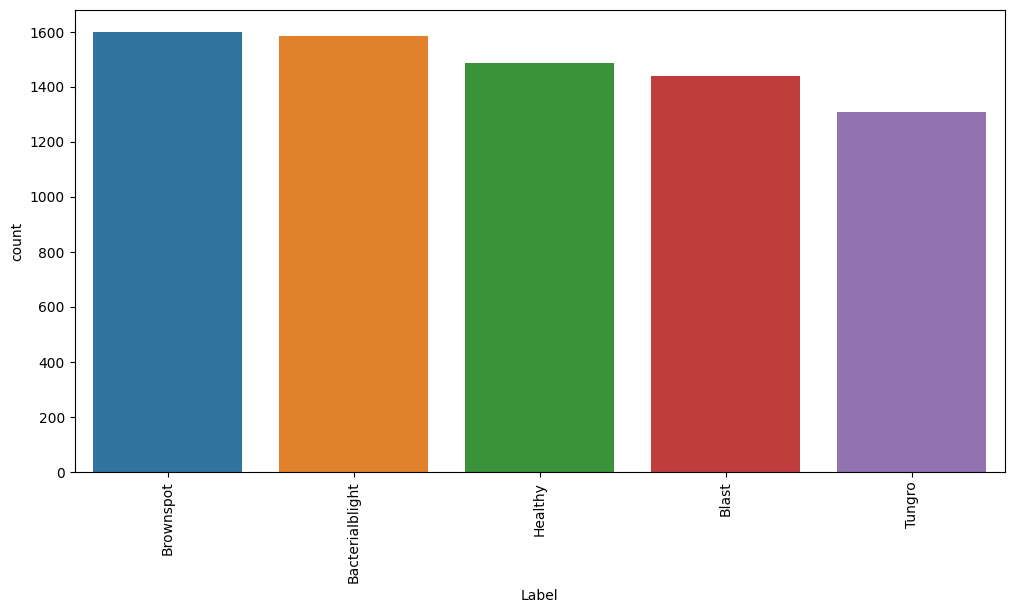

In [5]:
count_data = dataframe["Label"].value_counts()
sorted_data = count_data.sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.countplot(x=dataframe["Label"], order=sorted_data)

plt.xticks(rotation=90)
plt.show()

In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Parameters
data_dir = "/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images"
output_dir = "/kaggle/working/split_dataset"
train_ratio = 0.7  # 70% for training
val_ratio = 0.2    # 20% for validation
test_ratio = 0.1   # 10% for testing

# Create output directories
os.makedirs(output_dir, exist_ok=True)
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'validation')
test_dir = os.path.join(output_dir, 'test')

for directory in [train_dir, val_dir, test_dir]:
    os.makedirs(directory, exist_ok=True)

# Iterate through the dataset directory
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    if os.path.isdir(class_path):  # Process only directories (classes)
        # Create class directories in train, validation, and test folders
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        # Get all image file paths for the current class
        images = [os.path.join(class_path, img) for img in os.listdir(class_path) if img.endswith(('.jpg', '.png', '.jpeg'))]
        
        # Split into train, validation, and test sets
        train_images, temp_images = train_test_split(images, test_size=(1 - train_ratio), random_state=42)
        val_images, test_images = train_test_split(temp_images, test_size=test_ratio / (val_ratio + test_ratio), random_state=42)
        
        # Move images to respective folders
        for img in train_images:
            shutil.copy(img, os.path.join(train_dir, class_name))
        for img in val_images:
            shutil.copy(img, os.path.join(val_dir, class_name))
        for img in test_images:
            shutil.copy(img, os.path.join(test_dir, class_name))

print(f"Dataset successfully split into:\n- {train_dir}\n- {val_dir}\n- {test_dir}")


Dataset successfully split into:
- /kaggle/working/split_dataset/train
- /kaggle/working/split_dataset/validation
- /kaggle/working/split_dataset/test


Found 7420 files belonging to 5 classes.
Using 5194 files for training.
Found 7420 files belonging to 5 classes.
Using 2226 files for validation.


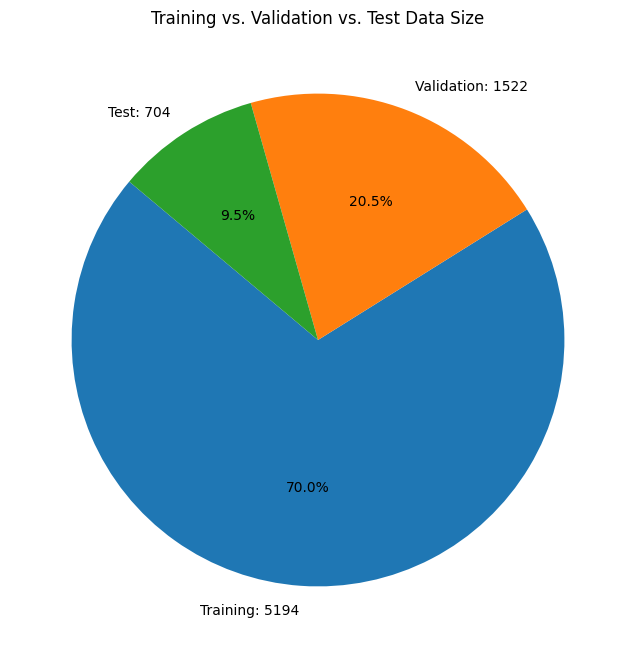

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Parameters
train_data_dir = "/kaggle/input/final-rice-leaf-dataset/Rice Leaf Disease Images"  # Path to your dataset
batch_size = 64
target_size = (224, 224)
validation_split = 0.3  # 30% for validation and test combined
test_split = 0.33  # Out of 30%, 33% will be used for test (10% of total dataset)
train_split = 1 - validation_split  # 70% for training

# Load the dataset with validation_split argument
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="training",  # Load training data
    seed=100,
    image_size=target_size,
    batch_size=batch_size,
)

# Now load the validation data
validation_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="validation",  # Load validation data
    seed=100,
    image_size=target_size,
    batch_size=batch_size,
)

# Manually split the validation data into validation and test sets (10% for test)
validation_size = len(validation_data)  # Total validation size
test_size = int(validation_size * test_split)  # 10% for testing
validation_size = validation_size - test_size  # Remaining for validation

# Now create the test data by taking the first 10% from validation_data
test_data = validation_data.take(test_size)
validation_data = validation_data.skip(test_size)

# Function to calculate dataset size
def get_dataset_size(dataset):
    return sum([len(batch[0]) for batch in dataset])

# Dataset sizes
train_size = get_dataset_size(full_dataset)
validation_size = get_dataset_size(validation_data)
test_size = get_dataset_size(test_data)

# Plot pie chart
sizes = [train_size, validation_size, test_size]
labels = ['Training', 'Validation', 'Test']
sizes_labels = [f'{label}: {size}' for label, size in zip(labels, sizes)]

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=sizes_labels, autopct='%1.1f%%', startangle=140)
plt.title('Training vs. Validation vs. Test Data Size')
plt.show()


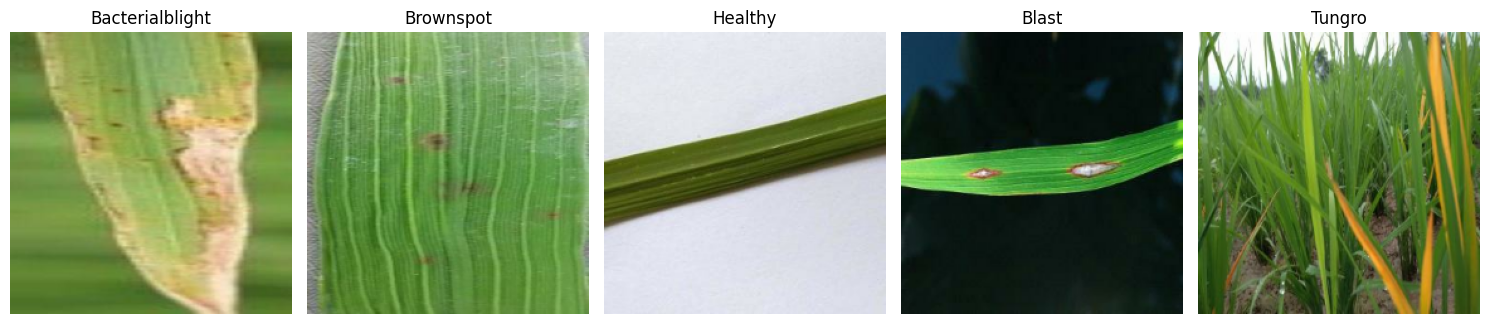

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Get the class names from the training dataset
class_labels = train_data.class_names  # Use train_data to get class names

# Visualize images from the training dataset
plt.figure(figsize=(15, len(class_labels) // 5 * 4))
displayed_classes = set()  # Track displayed classes

for images, labels in train_data.take(1):  # Take one batch of data
    for i in range(len(labels)):
        class_name = class_labels[labels[i].numpy()]  # Convert tensor to integer index
        if class_name not in displayed_classes:
            ax = plt.subplot((len(class_labels) + 4) // 5, 5, len(displayed_classes) + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_name)
            plt.axis("off")
            displayed_classes.add(class_name)
        if len(displayed_classes) == len(class_labels):
            break
    if len(displayed_classes) == len(class_labels):
        break

plt.tight_layout()
plt.show()


In [15]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16

# Number of classes (adjust to your dataset)
num_classes = len(class_labels)  # Ensure `class_labels` is defined

# Load the base model (VGG-16) with ImageNet weights, without the top classification layer
base_model = VGG16(
    input_shape=(224, 224, 3),  # Explicitly set input shape
    include_top=False,          # Exclude the fully connected top layer
    weights='imagenet'          # Use pre-trained ImageNet weights
)

base_model.trainable = False  # Freeze the base model

# Build the custom model
keras_model = Sequential([
    base_model,  # Add the pre-trained base model
    GlobalAveragePooling2D(),  # Use Global Average Pooling instead of Flatten
    Dense(256, activation='relu'),  # Fully connected layer with 256 neurons
    Dropout(0.5),  # Add dropout for regularization
    Dense(num_classes, activation='softmax')  # Final output layer for classification
])

# Provide a dummy input to initialize the model (use the input shape from VGG16)
keras_model.build(input_shape=(None, 224, 224, 3))

# Compile the model
keras_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Display the model summary
keras_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

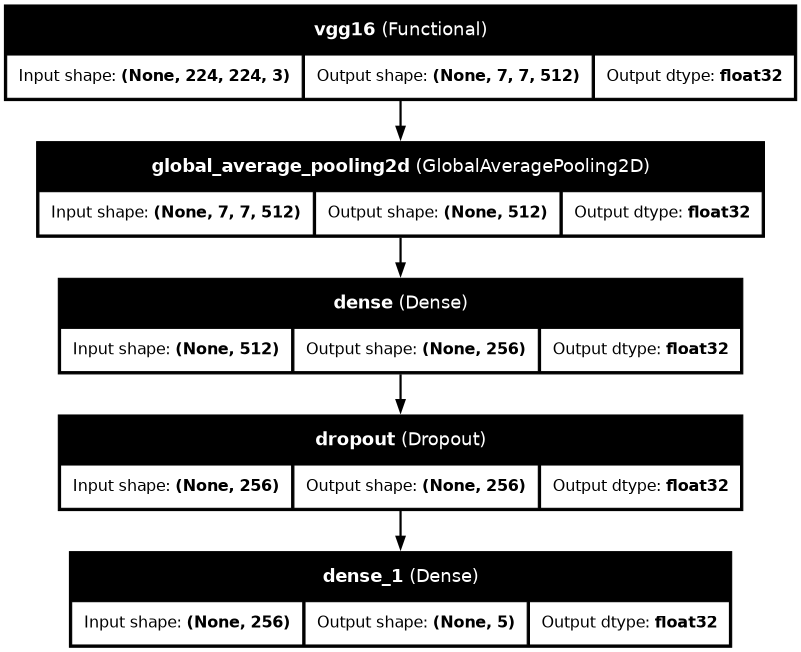

In [16]:
# Plot the model architecture
tf.keras.utils.plot_model(keras_model, to_file='keras_model.png', show_shapes=True, 
                          show_layer_names=True,show_dtype=True,dpi=80)

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Number of classes (adjust this according to your dataset)
num_classes = len(class_labels)

# Callback to save the model with the best performance
checkpoint = ModelCheckpoint(
    "my_keras_model.keras",   # Use .keras extension
    save_best_only=True,      # Save only the best model
    monitor="val_loss",       # Monitor validation loss
    mode="min",               # Save the model with the minimum validation loss
    verbose=1                 # Print saving details
)

# Callback to stop training early if the model's performance does not improve
early_stopping = EarlyStopping(
    patience=3,               # Number of epochs to wait for improvement
    restore_best_weights=True, # Restore weights from the best epoch
    monitor="val_loss",        # Monitor validation loss
    mode="min",                # Stop when validation loss stops improving
    verbose=1                 # Print stopping details
)



Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.6955 - loss: 1.7646 
Epoch 1: val_loss improved from inf to 0.10912, saving model to my_keras_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 1689s 21s/step - accuracy: 0.6970 - loss: 1.7537 - val_accuracy: 0.9612 - val_loss: 0.1091
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.9371 - loss: 0.1685 
Epoch 2: val_loss improved from 0.10912 to 0.04813, saving model to my_keras_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 1682s 21s/step - accuracy: 0.9372 - loss: 0.1683 - val_accuracy: 0.9829 - val_loss: 0.0481
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.9673 - loss: 0.0913 
Epoch 3: val_loss improved from 0.04813 to 0.03286, saving model to my_keras_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 1677s 21s/step - accuracy: 0.9674 - loss: 0.0912 - val_accuracy: 0.9908 - val_loss: 0.0329
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.9790 - loss: 0.0586 
Epoch 4: val_loss improved from 0.03286 to 

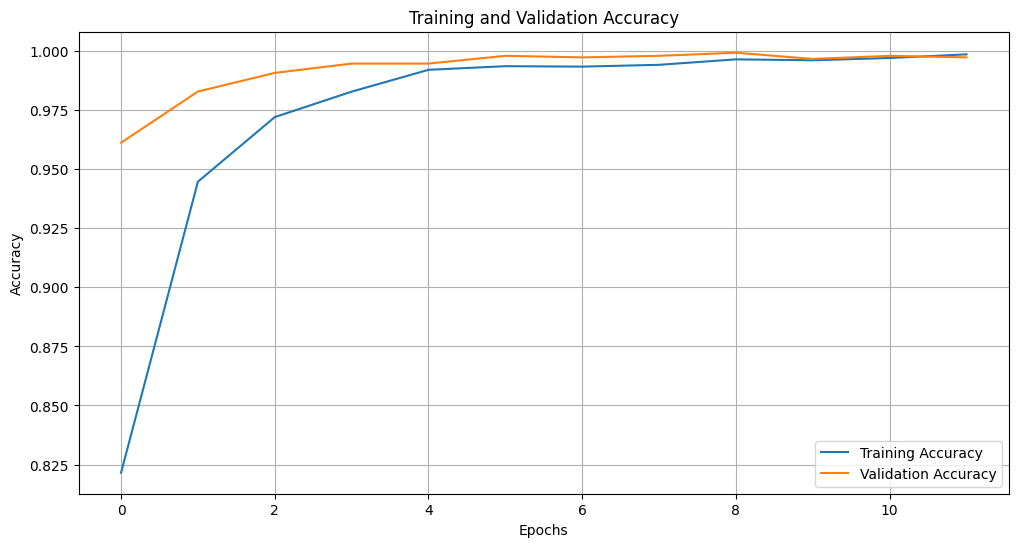

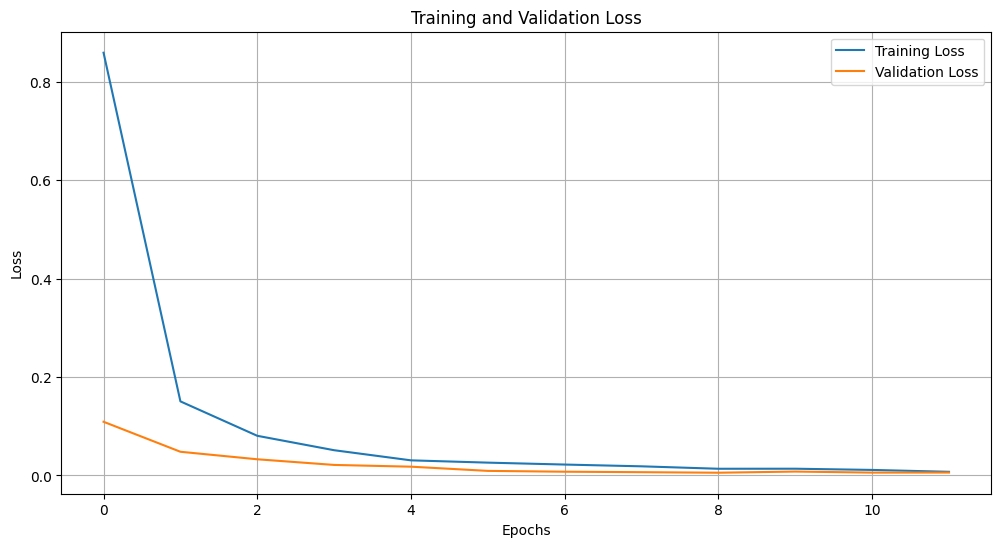

In [18]:
# Compile the Keras model
keras_model.compile(
    optimizer='Adam',  
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']  
)

# Train the model and track the history
history = keras_model.fit(
    full_dataset,                 # Training data generator
    epochs=20,                    # Number of epochs
    validation_data=validation_data,  # Validation data generator
    callbacks=[checkpoint, early_stopping],  # Callbacks for saving and early stopping
    verbose=1                     # Print training details
)

# After training, evaluate the model on the test set
test_loss, test_accuracy = keras_model.evaluate(test_data, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot training and validation accuracy over epochs
plt.figure(figsize=(12, 6))

# Training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')

# Validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Optionally, plot the training and validation loss as well
plt.figure(figsize=(12, 6))

# Training loss
plt.plot(history.history['loss'], label='Training Loss')

# Validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Model

# Define input shape and number of classes
input_shape = (224, 224, 3)
num_classes = 45  # Update with the actual number of classes

# Load base models
def load_base_model(model_class, input_shape, trainable=False):
    base_model = model_class(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = trainable
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # Add classification head
    ])
    return model

# Load the base models
model_1 = load_base_model(tf.keras.applications.MobileNetV3Small, input_shape)
model_2 = load_base_model(tf.keras.applications.EfficientNetB0, input_shape)
model_3 = load_base_model(tf.keras.applications.ResNet50, input_shape)
model_4 = load_base_model(tf.keras.applications.VGG19, input_shape)  # Add VGG19 as the fourth model

# Compile the models
for model in [model_1, model_2, model_3, model_4]:
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train each base model independently
# Assuming `train_data`, `train_labels`, `val_data`, and `val_labels` are prepared
model_1.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels))
model_2.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels))
model_3.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels))
model_4.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels))

# Generate predictions from the base models on the training data
pred_1 = model_1.predict(train_data)
pred_2 = model_2.predict(train_data)
pred_3 = model_3.predict(train_data)
pred_4 = model_4.predict(train_data)

# Combine predictions into a single dataset for the meta-model
meta_train_input = np.concatenate([pred_1, pred_2, pred_3, pred_4], axis=1)

# Generate predictions for the validation set
val_pred_1 = model_1.predict(val_data)
val_pred_2 = model_2.predict(val_data)
val_pred_3 = model_3.predict(val_data)
val_pred_4 = model_4.predict(val_data)

# Combine validation predictions for the meta-model
meta_val_input = np.concatenate([val_pred_1, val_pred_2, val_pred_3, val_pred_4], axis=1)

# Define the meta-model
meta_input = Input(shape=(meta_train_input.shape[1],))
x = Dense(128, activation='relu')(meta_input)
x = Dropout(0.5)(x)
meta_output = Dense(num_classes, activation='softmax')(x)

meta_model = Model(inputs=meta_input, outputs=meta_output)

# Compile the meta-model
meta_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the meta-model
meta_model.fit(meta_train_input, train_labels, validation_data=(meta_val_input, val_labels), epochs=10)

# Evaluate the stacking ensemble on the test data
test_pred_1 = model_1.predict(test_data)
test_pred_2 = model_2.predict(test_data)
test_pred_3 = model_3.predict(test_data)
test_pred_4 = model_4.predict(test_data)

# Combine test predictions for the meta-model
meta_test_input = np.concatenate([test_pred_1, test_pred_2, test_pred_3, test_pred_4], axis=1)

# Make final predictions
final_predictions = meta_model.predict(meta_test_input)
